In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os

In [11]:
# Выбранные датасеты: 01, 02, 03
datasets = {
    'ds1': 'data/S07-hw-dataset-01.csv',
    'ds2': 'data/S07-hw-dataset-02.csv',
    'ds3': 'data/S07-hw-dataset-03.csv'
}

data_frames = {}
for name, path in datasets.items():
    df = pd.read_csv(path)
    data_frames[name] = df
    print(f"Dataset {name}:")
    print(df.head())
    print(df.info())
    print(df.describe())
    print(f"Missing values: {df.isnull().sum().sum()}")
    print("\n")

Dataset ds1:
   sample_id        f01        f02       f03         f04        f05  \
0          0  -0.536647 -69.812900 -0.002657   71.743147 -11.396498   
1          1  15.230731  52.727216 -1.273634 -104.123302  11.589643   
2          2  18.542693  77.317150 -1.321686 -111.946636  10.254346   
3          3 -12.538905 -41.709458  0.146474   16.322124   1.391137   
4          4  -6.903056  61.833444 -0.022466  -42.631335   3.107154   

         f06        f07       f08  
0 -12.291287  -6.836847 -0.504094  
1  34.316967 -49.468873  0.390356  
2  25.892951  44.595250  0.325893  
3   2.014316 -39.930582  0.139297  
4  -5.471054   7.001149  0.131213  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sample_id  12000 non-null  int64  
 1   f01        12000 non-null  float64
 2   f02        12000 non-null  float64
 3   f03        12000 non-null  floa

In [12]:
# Препроцессинг
preprocessed_data = {}
scalers = {}

for name, df in data_frames.items():
    sample_ids = df['sample_id']
    X = df.drop('sample_id', axis=1)
    
    # Масштабирование
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    preprocessed_data[name] = (X_scaled, sample_ids)
    scalers[name] = scaler
    
    print(f"Dataset {name} preprocessed. Shape: {X_scaled.shape}")

Dataset ds1 preprocessed. Shape: (12000, 8)
Dataset ds2 preprocessed. Shape: (8000, 3)
Dataset ds3 preprocessed. Shape: (15000, 4)


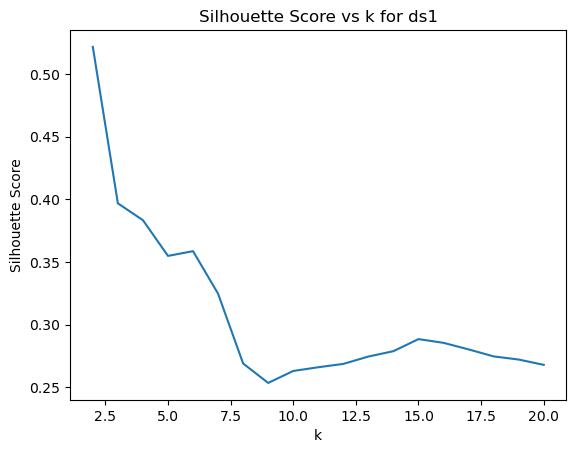

Best k for ds1: 2


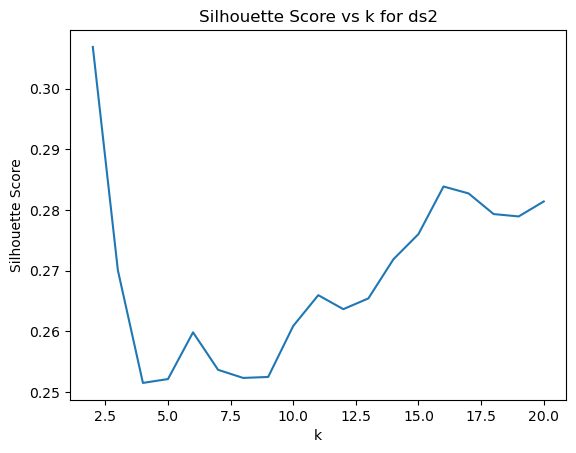

Best k for ds2: 2


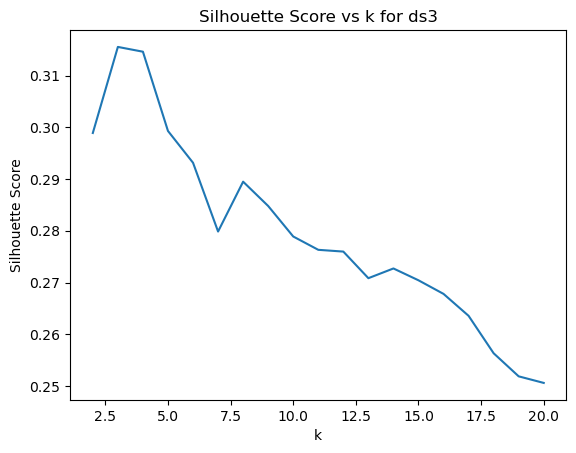

Best k for ds3: 3


In [13]:
# Функция для подбора k в KMeans
def evaluate_kmeans(X, k_range):
    silhouettes = []
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        if len(set(labels)) > 1:
            sil = silhouette_score(X, labels)
        else:
            sil = -1
        silhouettes.append(sil)
    return silhouettes

k_range = range(2, 21)
kmeans_results = {}

for name, (X, _) in preprocessed_data.items():
    sils = evaluate_kmeans(X, k_range)
    kmeans_results[name] = sils
    
    plt.figure()
    plt.plot(k_range, sils)
    plt.title(f'Silhouette Score vs k for {name}')
    plt.xlabel('k')
    plt.ylabel('Silhouette Score')
    plt.savefig(f'artifacts/figures/silhouette_k_{name}.png')
    plt.show()
    
    best_k = k_range[np.argmax(sils)]
    print(f"Best k for {name}: {best_k}")

In [14]:
# DBSCAN подбор
from sklearn.neighbors import NearestNeighbors

def evaluate_dbscan(X, eps_range, min_samples_range):
    best_sil = -1
    best_params = None
    best_labels = None
    for eps in eps_range:
        for min_s in min_samples_range:
            db = DBSCAN(eps=eps, min_samples=min_s)
            labels = db.fit_predict(X)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            if n_clusters > 1:
                sil = silhouette_score(X, labels)
                if sil > best_sil:
                    best_sil = sil
                    best_params = (eps, min_s)
                    best_labels = labels
    return best_params, best_labels, best_sil

eps_range = np.arange(0.1, 2.0, 0.1)
min_samples_range = [3, 5, 7]

dbscan_results = {}

for name, (X, _) in preprocessed_data.items():
    best_params, labels, sil = evaluate_dbscan(X, eps_range, min_samples_range)
    dbscan_results[name] = (best_params, labels, sil)
    noise_ratio = (labels == -1).sum() / len(labels)
    print(f"DBSCAN for {name}: eps={best_params[0]}, min_samples={best_params[1]}, sil={sil:.3f}, noise={noise_ratio:.3f}")

DBSCAN for ds1: eps=1.7000000000000002, min_samples=3, sil=0.522, noise=0.000
DBSCAN for ds2: eps=0.8, min_samples=7, sil=0.336, noise=0.007
DBSCAN for ds3: eps=0.8, min_samples=3, sil=0.318, noise=0.001


In [15]:
# Метрики для лучших моделей
metrics_summary = {}

for name in preprocessed_data.keys():
    X, sample_ids = preprocessed_data[name]
    
    # KMeans лучший
    best_k = k_range[np.argmax(kmeans_results[name])]
    kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    kmeans_labels = kmeans.fit_predict(X)
    
    sil_k = silhouette_score(X, kmeans_labels)
    db_k = davies_bouldin_score(X, kmeans_labels)
    ch_k = calinski_harabasz_score(X, kmeans_labels)
    
    # DBSCAN лучший
    eps, min_s = dbscan_results[name][0]
    db_labels = dbscan_results[name][1]
    sil_db = dbscan_results[name][2]
    db_db = davies_bouldin_score(X, db_labels) if len(set(db_labels)) > 1 else float('inf')
    ch_db = calinski_harabasz_score(X, db_labels) if len(set(db_labels)) > 1 else 0
    noise_ratio = (db_labels == -1).sum() / len(db_labels)
    
    metrics_summary[name] = {
        'KMeans': {'sil': sil_k, 'db': db_k, 'ch': ch_k, 'params': {'k': best_k}},
        'DBSCAN': {'sil': sil_db, 'db': db_db, 'ch': ch_db, 'params': {'eps': eps, 'min_samples': min_s}, 'noise': noise_ratio}
    }
    
    print(f"{name} KMeans: sil={sil_k:.3f}, db={db_k:.3f}, ch={ch_k:.3f}")
    print(f"{name} DBSCAN: sil={sil_db:.3f}, db={db_db:.3f}, ch={ch_db:.3f}, noise={noise_ratio:.3f}")

# Сохранить метрики
with open('artifacts/metrics_summary.json', 'w') as f:
    json.dump(metrics_summary, f)

ds1 KMeans: sil=0.522, db=0.685, ch=11786.955
ds1 DBSCAN: sil=0.522, db=0.685, ch=11786.955, noise=0.000
ds2 KMeans: sil=0.307, db=1.323, ch=3573.393
ds2 DBSCAN: sil=0.336, db=6.144, ch=10.910, noise=0.007
ds3 KMeans: sil=0.316, db=1.158, ch=6957.163
ds3 DBSCAN: sil=0.318, db=5.636, ch=10.118, noise=0.001


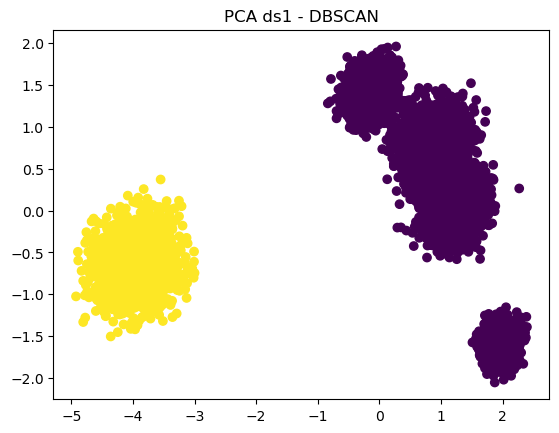

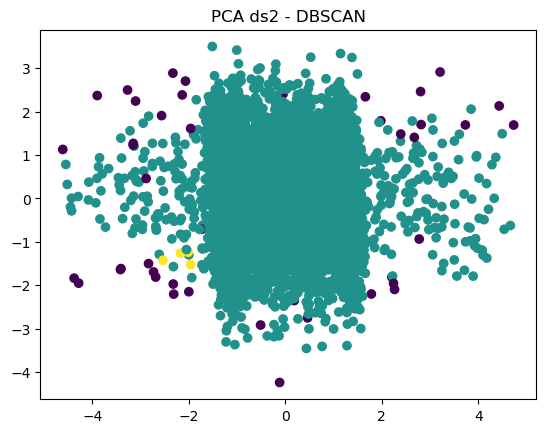

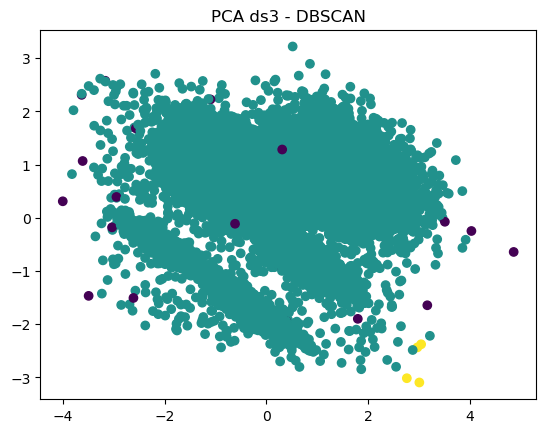

In [16]:
# Визуализация PCA
best_configs = {}

for name in preprocessed_data.keys():
    X, sample_ids = preprocessed_data[name]
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    # Выбрать лучший: по silhouette
    sil_k = metrics_summary[name]['KMeans']['sil']
    sil_db = metrics_summary[name]['DBSCAN']['sil']
    
    if sil_k > sil_db:
        best_method = 'KMeans'
        best_labels = KMeans(n_clusters=metrics_summary[name]['KMeans']['params']['k'], random_state=42, n_init=10).fit_predict(X)
    else:
        best_method = 'DBSCAN'
        best_labels = dbscan_results[name][1]
    
    best_configs[name] = {'method': best_method, 'params': metrics_summary[name][best_method]['params']}
    
    plt.figure()
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, cmap='viridis')
    plt.title(f'PCA {name} - {best_method}')
    plt.savefig(f'artifacts/figures/pca_{name}.png')
    plt.show()

# Сохранить best_configs
with open('artifacts/best_configs.json', 'w') as f:
    json.dump(best_configs, f)

In [17]:
# Устойчивость для ds1
from sklearn.metrics import adjusted_rand_score

X, _ = preprocessed_data['ds1']
best_k = metrics_summary['ds1']['KMeans']['params']['k']

labels_list = []
for seed in [42, 123, 456, 789, 101]:
    kmeans = KMeans(n_clusters=best_k, random_state=seed, n_init=10)
    labels = kmeans.fit_predict(X)
    labels_list.append(labels)

aris = []
for i in range(len(labels_list)):
    for j in range(i+1, len(labels_list)):
        ari = adjusted_rand_score(labels_list[i], labels_list[j])
        aris.append(ari)

print(f"ARI between runs: {aris}")
print(f"Mean ARI: {np.mean(aris):.3f}, Std: {np.std(aris):.3f}")

ARI between runs: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
Mean ARI: 1.000, Std: 0.000


In [18]:
# Сохранить labels
for name in preprocessed_data.keys():
    X, sample_ids = preprocessed_data[name]
    method = best_configs[name]['method']
    if method == 'KMeans':
        k = best_configs[name]['params']['k']
        model = KMeans(n_clusters=k, random_state=42, n_init=10)
    else:
        eps = best_configs[name]['params']['eps']
        min_s = best_configs[name]['params']['min_samples']
        model = DBSCAN(eps=eps, min_samples=min_s)
    
    labels = model.fit_predict(X)
    df_labels = pd.DataFrame({'sample_id': sample_ids, 'cluster_label': labels})
    df_labels.to_csv(f'artifacts/labels/labels_{name}.csv', index=False)